In [344]:
"""
Here we are using results from miniworld_slippery as results for the normal four rooms environment. There isn't any slippery in this setup due to a bug in the run loop, so the chosen actions were not replaced using slippery prob. A fix has been completed but it is reflected in the file full_train_miniworld_slippery.py
"""

"\nHere we are using results from miniworld_slippery as results for the normal four rooms environment. There isn't any slippery in this setup due to a bug in the run loop, so the chosen actions were not replaced using slippery prob. A fix has been completed but it is reflected in the file full_train_miniworld_slippery_fix.py\n"

In [345]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import hydra
import matplotlib.patches as mpatches


In [346]:
import wandb
from dm_env import specs
import uuid
from collections import OrderedDict

from helpers import modulators

In [347]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="../", version_base=None)
cfg = hydra.compose(config_name="full_train_miniworld_slippery")

In [348]:
if cfg.logging.mode == "full_train":
    experiment = cfg.domain.train.logging.experiment

elif cfg.logging.mode == "test":
    experiment = cfg.domain.test.logging.experiment

elif cfg.logging.mode == "pretrain":
    experiment = cfg.domain.pretrain.logging.experiment
elif cfg.logging.mode == "full_train_slippery":
    experiment = cfg.domain.train.logging.experiment + "_slippery"

elif cfg.logging.mode == "full_train_slippery_fix":
    experiment = cfg.domain.train.logging.experiment + "_slippery_fix"

else:
    raise ValueError("Invalid logging mode: {}".format(cfg.logging.mode))

In [349]:
moving_average_window = 10 # window size for moving average

In [350]:
api = wandb.Api()

project_name = "continual_rl" + "_" + cfg.logging.mode + "_" + experiment
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_of_runs: 208


In [351]:
for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["agent_feature_dim"] != 256:
        continue

    if run.config["domain_slippery_prob"] != 0.3:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/avg_episode_returns"])
    avg_episode_return = [
        row["eval/avg_episode_returns"] for row in avg_episode_returns_history
    ]

    avg_episode_length_history = run.scan_history(keys=["eval/avg_episode_length"])
    avg_episode_length = [
        row["eval/avg_episode_length"] for row in avg_episode_length_history
    ]

    steps_history = run.scan_history(keys=["eval/steps"])

    steps = [row["eval/steps"] for row in steps_history]

    task_history = run.scan_history(keys=["train/task"])
    task = [row["train/task"] for row in task_history]


    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue

    print("len(steps): ", len(steps))
    print("len(avg_episode_return): ", len(avg_episode_return))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/steps"] = steps
    temp["eval/episode_return"] = avg_episode_return
    temp["eval/avg_episode_length"] = avg_episode_length
    temp["train/task"] = task

    temp["eval/mvg_avg_episode_length"] = np.convolve(
        temp["eval/avg_episode_length"],
        np.ones((moving_average_window,))
        / moving_average_window,
        mode="valid",
    )

    temp["eval/mvg_avg_episode_length"] = np.pad(
        temp["eval/mvg_avg_episode_length"],
        (moving_average_window - 1, 0),
        "constant",
        constant_values=cfg.domain.max_episode_length,
    )

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

idx: 0
idx: 10
idx: 20
idx: 30
idx: 40
idx: 50
idx: 60
idx: 70
idx: 80
idx: 90
idx: 100
idx: 110
idx: 120
idx: 130
idx: 140
idx: 150
dqn
len(steps):  200
len(avg_episode_return):  200
dqn
len(steps):  200
len(avg_episode_return):  200
dqn
len(steps):  200
len(avg_episode_return):  200
dqn
len(steps):  200
len(avg_episode_return):  200
dqn
len(steps):  200
len(avg_episode_return):  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
idx: 160
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
sf_consolidation_params_continuous
len(ste

In [352]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["agent_seed"])

In [353]:
print(runs_df["agent_name"].unique())

['dqn' 'simple_sf_agent' 'sf_consolidation_params_continuous'
 'DQN_consolidation_params_continuous' 'simple_sf_online_ewc'
 'dqn_online_ewc'
 'sf_consolidation_params_continuous_softmax_attention_diff_unique'
 'DQN_plasticity_injection']


In [354]:
agents_new_names = {
    "dqn": "DQN",
    "DQN_consolidation_params_continuous": "DQN + SC",
    "simple_sf_agent": "SF",
    "sf_consolidation_params_continuous": "SF + SC",
    "dqn_online_ewc": "DQN + EWC",
    "simple_sf_online_ewc": "SF + EWC",
    "sf_consolidation_params_continuous_softmax_attention_diff_unique": "SF + SC + Attention",
    "DQN_plasticity_injection" : "DQN + Plasticity",
}

In [355]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn", agents_new_names["dqn"]
)

In [356]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_agent", agents_new_names["simple_sf_agent"]
)

In [357]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_consolidation_params_continuous", agents_new_names["DQN_consolidation_params_continuous"]
)

In [358]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous", agents_new_names["sf_consolidation_params_continuous"]
)

In [359]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn_online_ewc", agents_new_names["dqn_online_ewc"]
)

In [360]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_online_ewc", agents_new_names["simple_sf_online_ewc"]
)

In [361]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous_softmax_attention_diff_unique", agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]
)

In [362]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_plasticity_injection", agents_new_names["DQN_plasticity_injection"]
)

In [363]:
# print unique agent_name
print(runs_df["agent_name"].unique())

['DQN' 'SF' 'SF + SC' 'DQN + SC' 'SF + EWC' 'DQN + EWC'
 'SF + SC + Attention' 'DQN + Plasticity']


In [364]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# runs_df = runs_df.drop(columns=["agent_seed"])

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

             agent_name  agent_seed  \
0                   DQN          97   
1                   DQN         679   
2                   DQN         485   
3                   DQN         291   
4                   DQN         388   
5                    SF         388   
6                    SF         291   
7                    SF         679   
8                    SF         485   
9                    SF          97   
10              SF + SC         679   
11              SF + SC         194   
12              SF + SC         582   
13              SF + SC         291   
14              SF + SC         485   
15             DQN + SC         194   
16             DQN + SC         679   
17             DQN + SC         291   
18             DQN + SC         582   
19             DQN + SC          97   
20             SF + EWC         194   
21             SF + EWC         291   
22             SF + EWC          97   
23             SF + EWC         485   
24             SF + EWC  

In [365]:
color_code = {
    "DQN": "#1f77b4",
    "SF": "#ff7f0e",
    "DQN + SC": "#2ca02c",
    "SF + SC": "#9467bd",
    "DQN + Plasticity": "#d62728",
    # "DDPG + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#6F4E37",
    "DQN\n +SC": "#2ca02c",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention": "#6F4E37",
    "SF + EWC": "#e377c2",
    "DQN + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "DQN\n +EWC": "#bcbd22"
    # "SF + SC": "#ff7f0e",
    # "DDPG + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

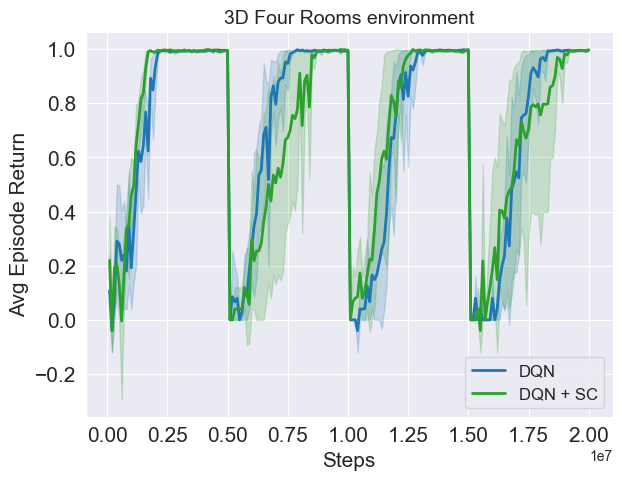

In [366]:
"""
This plot is to show how adding consolidation to Q-values are not very effective
"""

f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("3D Four Rooms environment", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Avg Episode Return", fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms" + "_consolidating_only_qvalues"
plt.savefig(filename + ".pdf")
plt.show()

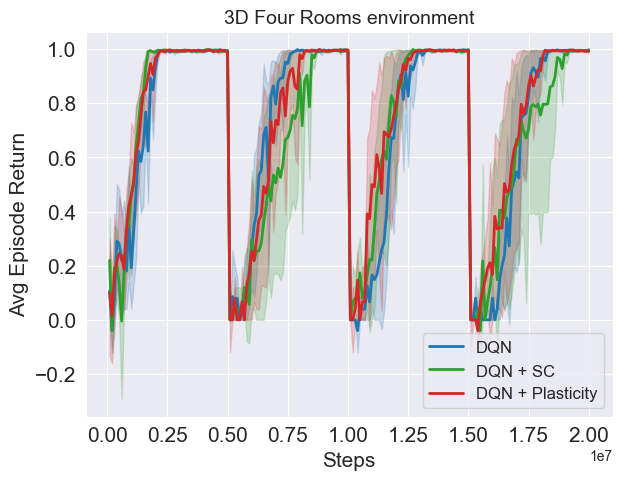

In [367]:
"""
This plot is to show how compare injecting plasticity vs consolidation to Q-values
"""

f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("3D Four Rooms environment", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Avg Episode Return", fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms" + "_plasticity_injection_vs_consolidation_q_values"
plt.savefig(filename + ".pdf")
plt.show()

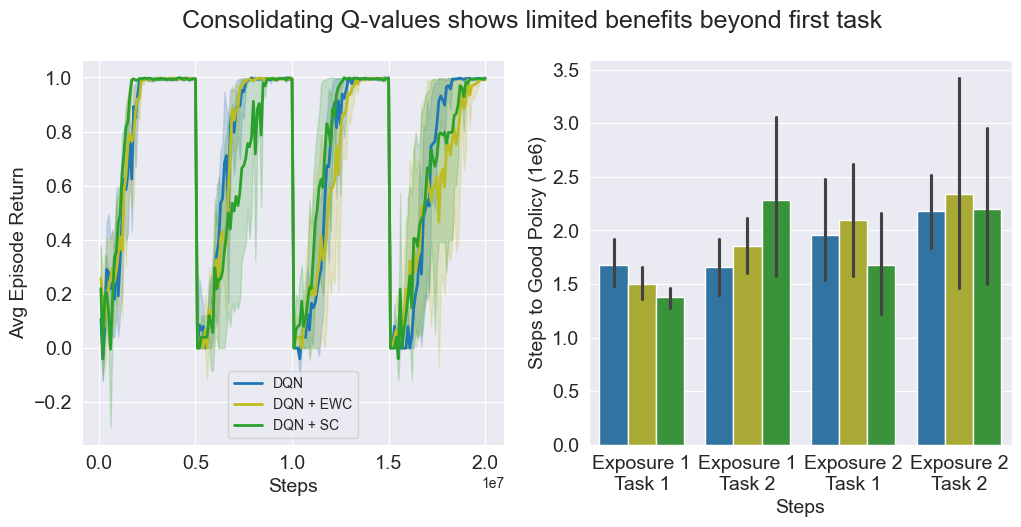

<Figure size 1400x1000 with 0 Axes>

In [383]:
"""
This plot is to compare the various consolidation techniques on Q-values
"""


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)


sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + EWC",
    "DQN + SC",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
plt.figure(figsize=(14, 10))
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

fig.suptitle("Consolidating Q-values shows limited benefits beyond first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=14)
axes[0].set_ylabel("Avg Episode Return", fontsize=14)
axes[0].tick_params(axis="x", labelsize=14)
axes[0].tick_params(axis="y", labelsize=14)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("Steps", fontsize=14)
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
axes[1].tick_params(axis="x", labelsize=14)
axes[1].tick_params(axis="y", labelsize=14)
axes[1].legend_.remove()

filename = "consolidating_q_values_only_analysis_fourrooms"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()



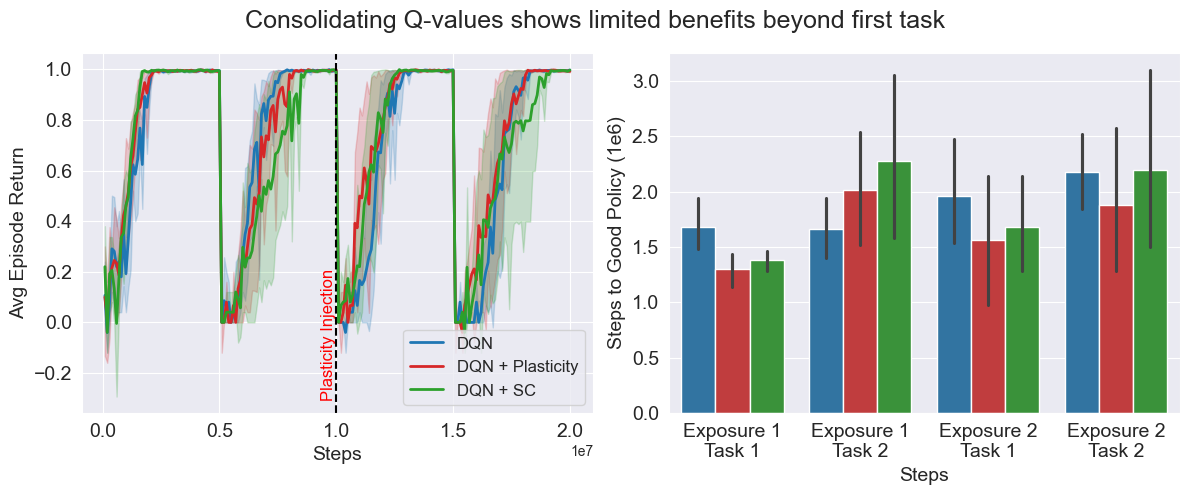

In [384]:
"""
This plot is to compare the plasticity injection vs consolidation on the Q-values
"""


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000
xline = 1e7

agent_order = [
    "DQN",
    "DQN + Plasticity",
    "DQN + SC",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

fig.suptitle("Consolidating Q-values shows limited benefits beyond first task", fontsize=18)

ymin, ymax = axes[0].get_ylim()

axes[0].set_xlabel("Steps", fontsize=14)
axes[0].set_ylabel("Avg Episode Return", fontsize=14)
axes[0].tick_params(axis="x", labelsize=14)
axes[0].tick_params(axis="y", labelsize=14)
axes[0].legend(loc="lower right", fontsize=12)
axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Injection",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=12
)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("Steps", fontsize=14)
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
axes[1].tick_params(axis="x", labelsize=14)
axes[1].tick_params(axis="y", labelsize=14)
axes[1].legend_.remove()

filename = "consolidation_vs_plasticity_injection_qvalues_analysis_fourrooms"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()



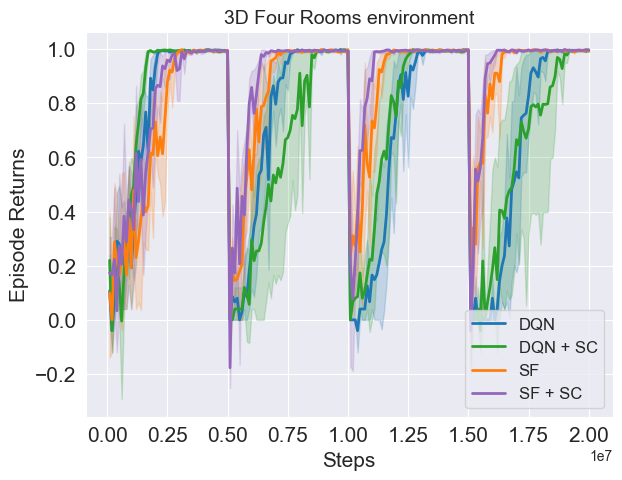

In [370]:
f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("3D Four Rooms environment", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Episode Returns", fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms" + "_consolidating_sf_leads_to_improvements"
plt.savefig(filename + ".pdf")
plt.show()

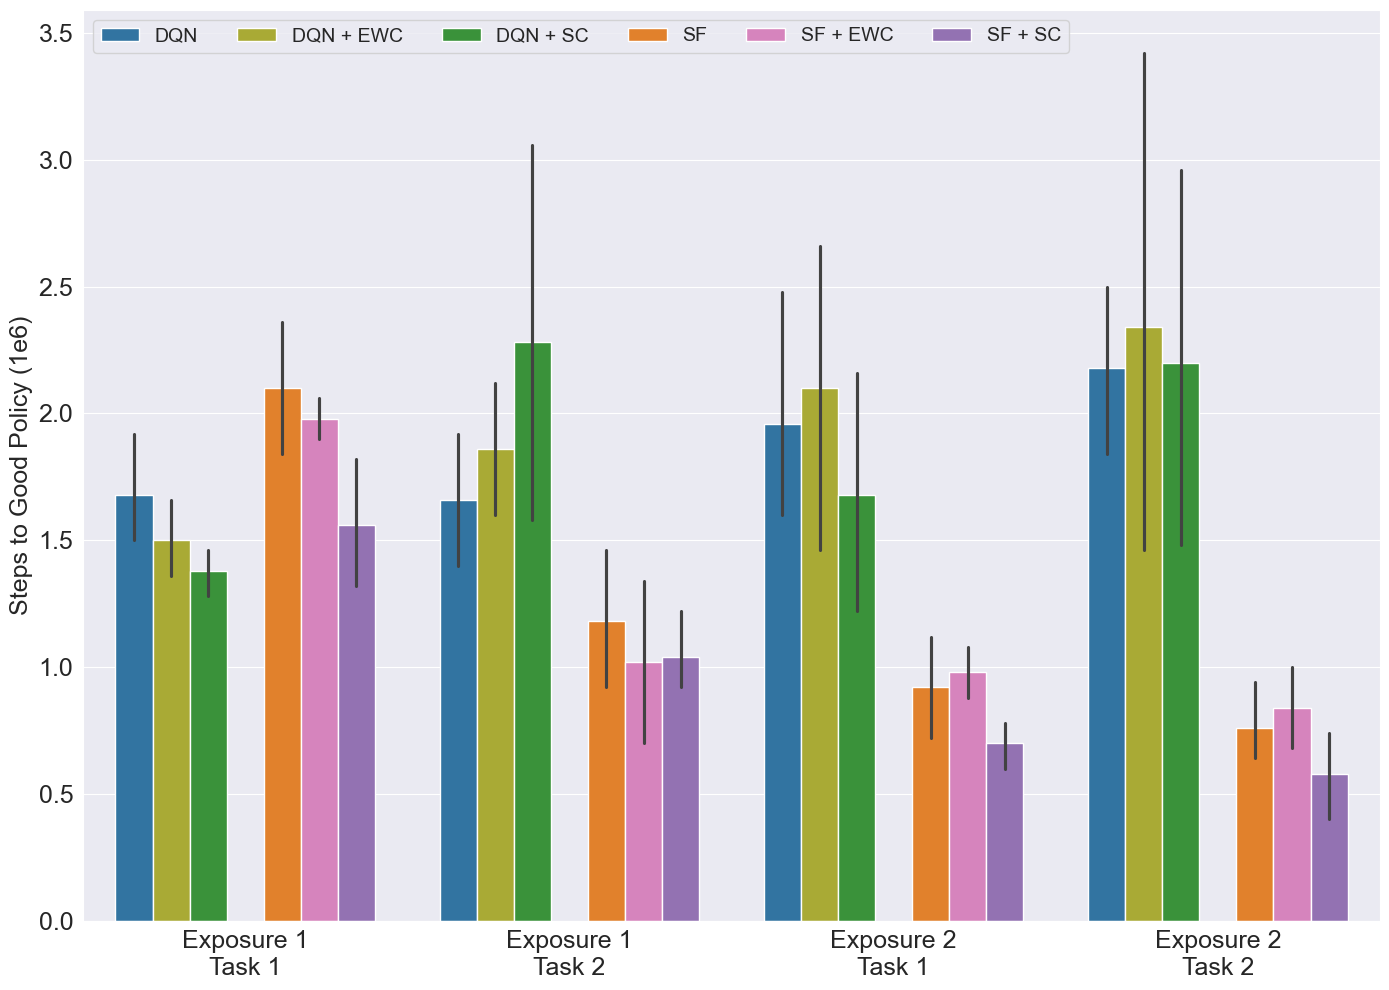

In [371]:
rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + EWC",
    "DQN + SC",

    " ",
    "SF",
    "SF + EWC",
    "SF + SC",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
)
# Remove spacer from legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[h for h, l in zip(handles, labels) if l != " "],
          labels=[l for l in labels if l != " "],
          title=None, loc="upper left", fontsize=14, ncol=len(agent_order))

ax.yaxis.get_offset_text().set_visible(False)
plt.ylabel("Steps to Good Policy (1e6)", fontsize=18)
plt.xlabel("", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
filename = "Steps_to_good_policy_fourrooms"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()


Bar: task=Exposure 1
Task 1, agent=DQN, height=1680000.0
Bar: task=Exposure 1
Task 2, agent=DQN, height=1660000.0
Bar: task=Exposure 2
Task 1, agent=DQN, height=1960000.0
Bar: task=Exposure 2
Task 2, agent=DQN, height=2180000.0
Bar: task=Exposure 1
Task 1, agent=DQN + SC, height=1380000.0
Bar: task=Exposure 1
Task 2, agent=DQN + SC, height=2280000.0
Bar: task=Exposure 2
Task 1, agent=DQN + SC, height=1680000.0
Bar: task=Exposure 2
Task 2, agent=DQN + SC, height=2200000.0
Bar: task=Exposure 1
Task 1, agent=SF, height=2100000.0
Bar: task=Exposure 1
Task 2, agent=SF, height=1180000.0
Bar: task=Exposure 2
Task 1, agent=SF, height=920000.0
Bar: task=Exposure 2
Task 2, agent=SF, height=760000.0
Bar: task=Exposure 1
Task 1, agent=SF + SC, height=1560000.0
Bar: task=Exposure 1
Task 2, agent=SF + SC, height=1040000.0
Bar: task=Exposure 2
Task 1, agent=SF + SC, height=700000.0
Bar: task=Exposure 2
Task 2, agent=SF + SC, height=580000.0


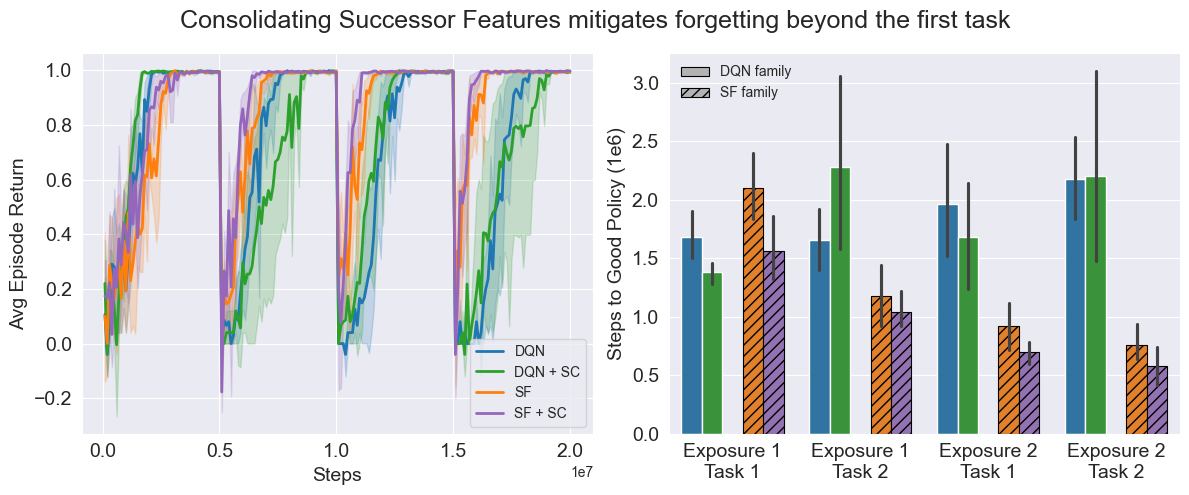

In [372]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + SC",
    " ",
    "SF",
    "SF + SC",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

x_order = ["Exposure 1\nTask 1", "Exposure 1\nTask 2",
           "Exposure 2\nTask 1", "Exposure 2\nTask 2"]

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    order=x_order,
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# for i, bar in enumerate(axes[1].patches):
#     print(i, bar.get_x(), bar.get_height())

sf_set = {"SF", "SF + SC"}  # only hatch SF
patterns = {"SF": "///", "SF + SC": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# Create two dummy handles
# 1) Build the small “style” legend
plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="DQN family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SF family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper left", frameon=False, fontsize=10)

fig.suptitle("Consolidating Successor Features mitigates forgetting beyond the first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=14)
axes[0].set_ylabel("Avg Episode Return", fontsize=14)
axes[0].tick_params(axis="x", labelsize=14)
axes[0].tick_params(axis="y", labelsize=14)
axes[0].legend(loc="lower right")

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
axes[1].tick_params(axis="x", labelsize=14)
axes[1].tick_params(axis="y", labelsize=14)

filename = "consolidating_q_values_vs_sf_analysis_fourrooms"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()

Bar: task=Exposure 1
Task 1, agent=DQN + EWC, height=1500000.0
Bar: task=Exposure 1
Task 2, agent=DQN + EWC, height=1860000.0
Bar: task=Exposure 2
Task 1, agent=DQN + EWC, height=2100000.0
Bar: task=Exposure 2
Task 2, agent=DQN + EWC, height=2340000.0
Bar: task=Exposure 1
Task 1, agent=DQN + SC, height=1380000.0
Bar: task=Exposure 1
Task 2, agent=DQN + SC, height=2280000.0
Bar: task=Exposure 2
Task 1, agent=DQN + SC, height=1680000.0
Bar: task=Exposure 2
Task 2, agent=DQN + SC, height=2200000.0
Bar: task=Exposure 1
Task 1, agent=SF + EWC, height=1980000.0
Bar: task=Exposure 1
Task 2, agent=SF + EWC, height=1020000.0
Bar: task=Exposure 2
Task 1, agent=SF + EWC, height=980000.0
Bar: task=Exposure 2
Task 2, agent=SF + EWC, height=840000.0
Bar: task=Exposure 1
Task 1, agent=SF + SC, height=1560000.0
Bar: task=Exposure 1
Task 2, agent=SF + SC, height=1040000.0
Bar: task=Exposure 2
Task 1, agent=SF + SC, height=700000.0
Bar: task=Exposure 2
Task 2, agent=SF + SC, height=580000.0


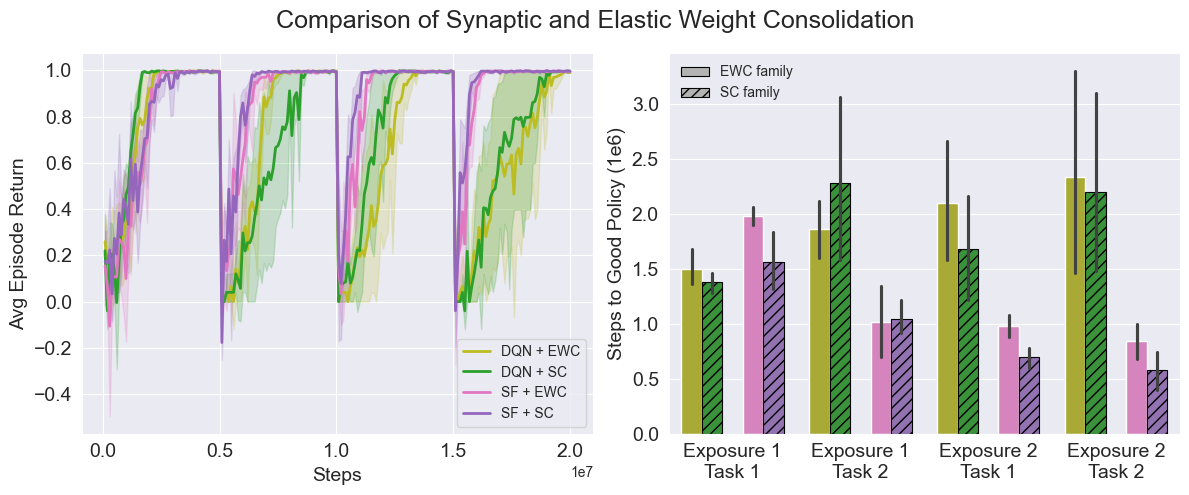

In [373]:
"""
This plot is to compare synaptic consolidation vs EWC
"""


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_online_ewc"]],
    label=agents_new_names["simple_sf_online_ewc"],
    color=color_code[agents_new_names["simple_sf_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF + EWC",
    "SF + SC",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

sf_set = {"DQN + SC", "SF + SC"}  # only hatch SF
patterns = {"DQN + SC": "///", "SF + SC": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

fig.suptitle("Comparison of Synaptic and Elastic Weight Consolidation", fontsize=18)

plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="EWC family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SC family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper left", frameon=False, fontsize=10)

axes[0].set_xlabel("Steps", fontsize=14)
axes[0].set_ylabel("Avg Episode Return", fontsize=14)
axes[0].tick_params(axis="x", labelsize=14)
axes[0].tick_params(axis="y", labelsize=14)
axes[0].legend(loc="lower right")


axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
axes[1].tick_params(axis="x", labelsize=14)
axes[1].tick_params(axis="y", labelsize=14)

filename = "ewc_vs_synaptic_consolidation_fourrooms"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()

In [374]:
cfg

{'agent_lr': 0.0001,
 'train_lr': 0.0001,
 'agent_name': 'DQN_plasticity_injection',
 'agent_seed': 485,
 'domain_gap': 0.27,
 'train_seed': 485,
 'agent_nstep': 10,
 'domain_name': 'MiniworldTwoTasks',
 'domain_seed': 485,
 'agent_policy': 'learned',
 'env_obs_type': 'pixels',
 'logging_mode': 'full_train_slippery',
 'replay_nstep': 10,
 'train_sf_dim': 128,
 'agent_lr_task': 0,
 'env_obs_shape': [60, 80, 3],
 'agent__target_': 'agent.DQN_plasticity_injection_agent.DQN_Plasticity_Injection_Agent',
 'agent_discount': 0.99,
 'agent_env_type': 'miniworld',
 'agent_obs_type': 'pixels',
 'agent_work_dir': '/home/chuaraym/CRL_flax',
 'domain_max_pos': 6.34,
 'domain_min_pos': -6.34,
 'paths_work_dir': '/home/chuaraym/CRL_flax',
 'agent_log_grads': False,
 'agent_obs_shape': [60, 80, 3],
 'agent_optimizer': 'adam',
 'agent_use_wandb': True,
 'domain__target_': 'domain.Miniworld_Two_Tasks.MiniworldTwoTasks',
 'domain_discount': 0.99,
 'domain_env_type': 'miniworld',
 'domain_goal_vis': True,


In [375]:
# print(df_hits["first_below_local"])
print(df_hits[df_hits["task"] == 1][["agent_name", "first_below_local", "task"]])

                                            agent_name  first_below_local  \
1                                                  dqn          1600000.0   
5                                                  dqn          1300000.0   
9                                                  dqn          1400000.0   
13                                                 dqn          1900000.0   
17                                                 dqn          2100000.0   
21                                     simple_sf_agent          1400000.0   
25                                     simple_sf_agent          1100000.0   
29                                     simple_sf_agent          1600000.0   
33                                     simple_sf_agent           700000.0   
37                                     simple_sf_agent          1100000.0   
41                  sf_consolidation_params_continuous           900000.0   
45                  sf_consolidation_params_continuous           900000.0   